In [1]:
from PlanckConv.core_functions import SkyData,PlanckDetectorsData,compute_convolved_planck_map
import matplotlib.pyplot as plt
import healpy as hp
import marimo as mo

In [2]:

nside=128
lmax=2*nside

In [3]:
mo.md(r"""
#Load the detector informations: blms and h-maps
""")

_md()

In [4]:


det_planck_data=PlanckDetectorsData(detector_set="100", #you can refer to list_planck() to check the different set of detectors 
                                    path_to_blms="inputs/gaussian_elliptical_beams", 
                                    path_to_pol_moments="inputs/polmoments_ns0128", # planck h-maps are called polmoments
                                    path_to_rimo="inputs/RIMOs/RIMO_HFI_npipe5v16_symmetrized.fits",
                                    mmax_beam=4,
                                    lmax=lmax,
                                    blm_polar_efficiency="Ideal",
                                    ref_frame_beams="Dxx",
                                    ref_frame_polmoments="Pxx")
det_planck_data.fill_blms_dict()

det_planck_data.fill_h_maps_dict()

Loading RIMO from inputs/RIMOs/RIMO_HFI_npipe5v16_symmetrized.fits
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
maximum l in file: 256, maximum m in file: 256
Renormalizing the beam
Blms in file contains polarization.
Loaded hits+spins in 0.02s
Loaded hits+spins in 0.02s
Loaded hits+spins in 0.02s
Load

In [5]:
mo.md(r"""
# Set the sky alms
""")

_md()

In [6]:
sky=SkyData(nside=nside,lmax=lmax,apply_pixel_window=True)
sky.fill_cmb_alms(det_planck_data.detector_names,
                  path_to_cl="inputs/Cls_Planck2018_for_PTEP_2020_r0.fits",
                  seed_cmb=0
                )
#Or you can provide whatever set of alms you want with SkyData.set_alms_dict(alms_dict), with alms_dict is a dictionnary with a set of alms for each detector, the keys being the detector_names 

/home/camille/Documents/PhD/PlanckConv/PlanckConv/core_functions.py:122: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  alms = hp.synalm(cls=cls, lmax=lmax, verbose=False)


In [7]:
mo.md(r"""
# Generate the spin maps and run the Smarties mapmaking
""")

_md()

In [8]:
TQU_conv=compute_convolved_planck_map(sky_data=sky,
                                      detector_data=det_planck_data,                                                                                            inverse_mapmaking_matrix=None, # You can reuse the mapmaking matrix of a detector to avoid recomputing at each mapmaking
                                      return_inverse_mapmaking_matrix=False,
                                      output_directory=None
                                     )

Finishing the mapmaking process, computing the total maps...
Computing the spin coupled maps...
Coupled spins for spin 0: [(4, -4), (3, -3), (2, -2), (1, -1), (0, 0), (-1, 1), (-2, 2), (-3, 3), (-4, 4)]
Coupled spins for spin 2: [(6, -4), (5, -3), (4, -2), (3, -1), (2, 0), (1, 1), (0, 2), (-1, 3), (-2, 4)]
Coupled spins for spin -2: [(2, -4), (1, -3), (0, -2), (-1, -1), (-2, 0), (-3, 1), (-4, 2), (-5, 3), (-6, 4)]
Computing the final CMB fields...
Final CMB fields computed, transforming them into Spin_maps...


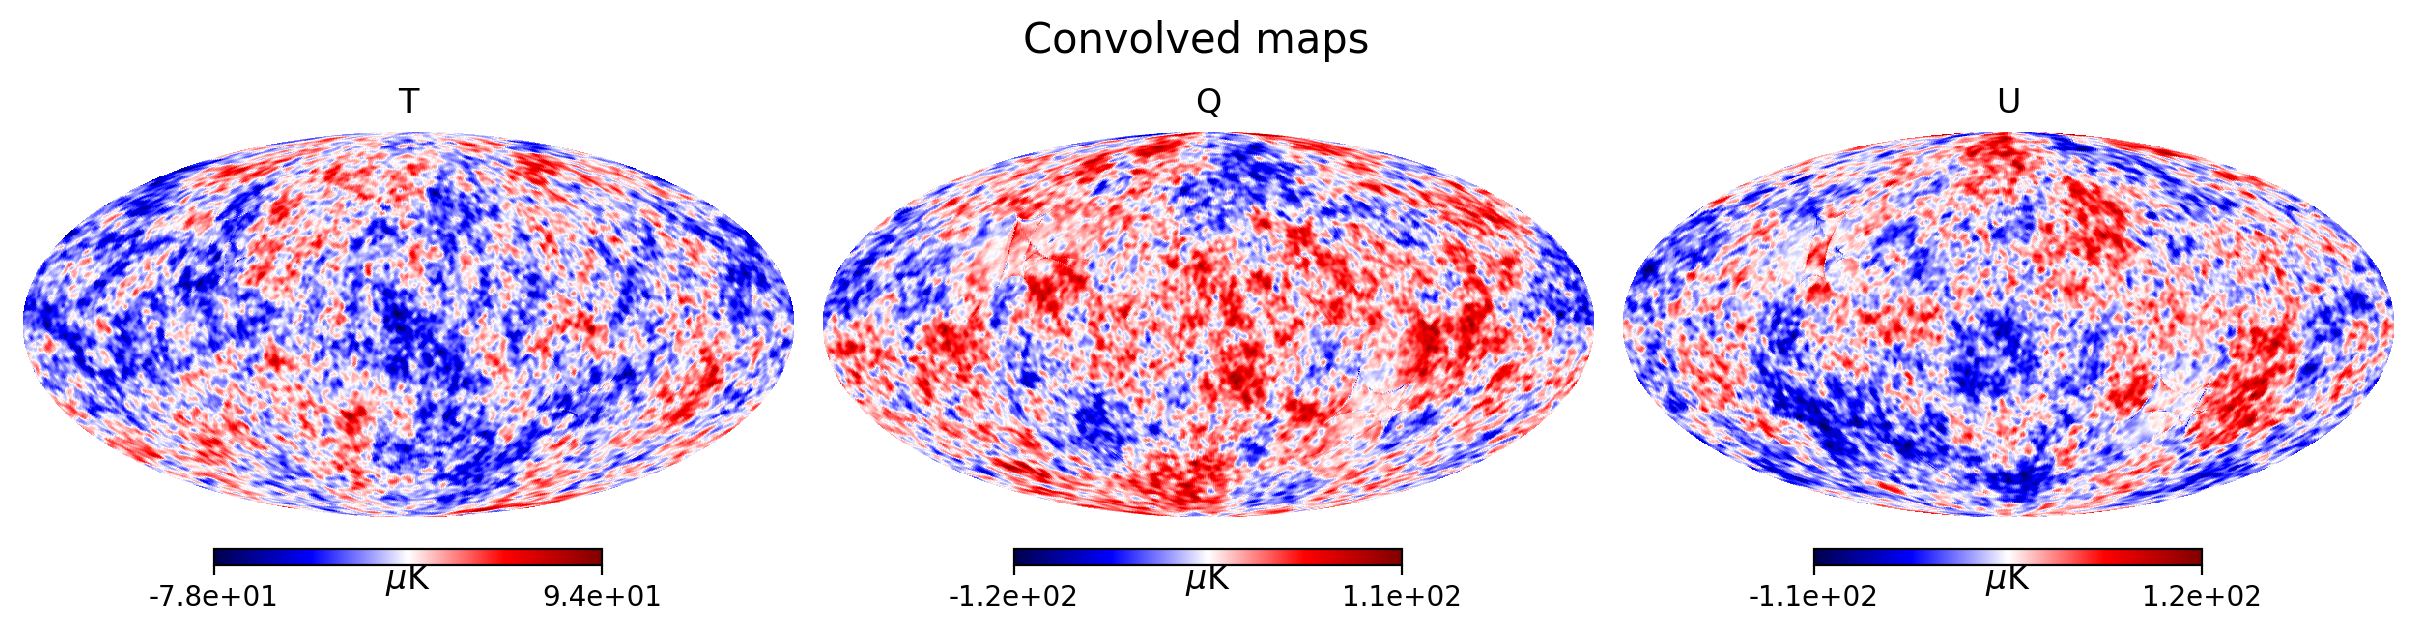

In [9]:


fig = plt.figure(figsize=(12, 3),dpi=200)
for i, label in enumerate(["T", "Q", "U"]):
    hp.mollview(
        TQU_conv[i],
        sub=(1, 3, i + 1),
        title=f"{label}",
        unit=r"$\mu$K",
        cmap="seismic",
        format="%.1e",
        cbar=True,
        fontsize={"":00}

    )
plt.suptitle("Convolved maps",fontsize=15)
plt.show()